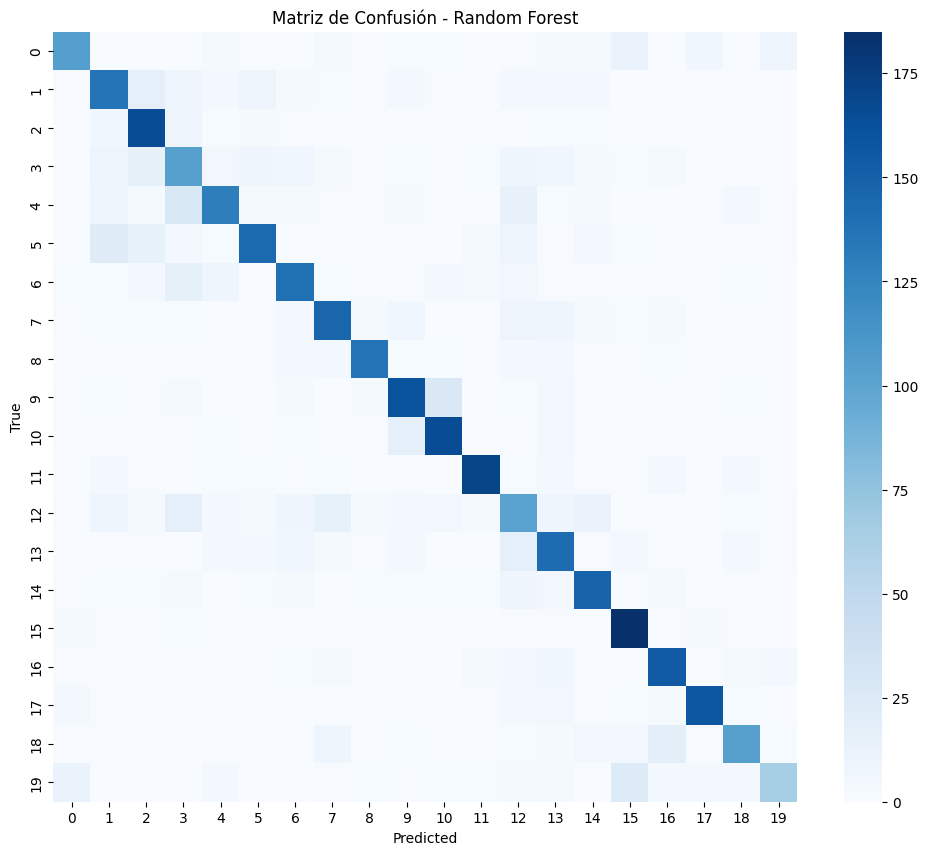

Reporte de clasificación:

                          precision    recall  f1-score   support

             alt.atheism       0.78      0.70      0.74       151
           comp.graphics       0.65      0.67      0.66       202
 comp.os.ms-windows.misc       0.71      0.85      0.77       195
comp.sys.ibm.pc.hardware       0.52      0.57      0.54       183
   comp.sys.mac.hardware       0.74      0.63      0.68       205
          comp.windows.x       0.77      0.67      0.72       215
            misc.forsale       0.72      0.72      0.72       193
               rec.autos       0.75      0.74      0.75       196
         rec.motorcycles       0.87      0.82      0.84       168
      rec.sport.baseball       0.75      0.76      0.75       211
        rec.sport.hockey       0.77      0.83      0.80       198
               sci.crypt       0.89      0.85      0.87       201
         sci.electronics       0.50      0.50      0.50       202
                 sci.med       0.63      0.73   

In [ ]:
# Instalación de librerías
!pip install -q scikit-learn matplotlib

# Importación de librerías necesarias
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar el conjunto de datos
newsgroups = fetch_20newsgroups(subset='all', shuffle=True, random_state=42)

# 2. Preprocesamiento con TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)  # Se reduce tamaño para t-SNE
X = vectorizer.fit_transform(newsgroups.data)
y = newsgroups.target

# 3. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Entrenar modelo Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Evaluación del modelo
y_pred = rf_model.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Reporte de clasificación
print("Reporte de clasificación:\n")
print(classification_report(y_test, y_pred, target_names=newsgroups.target_names))


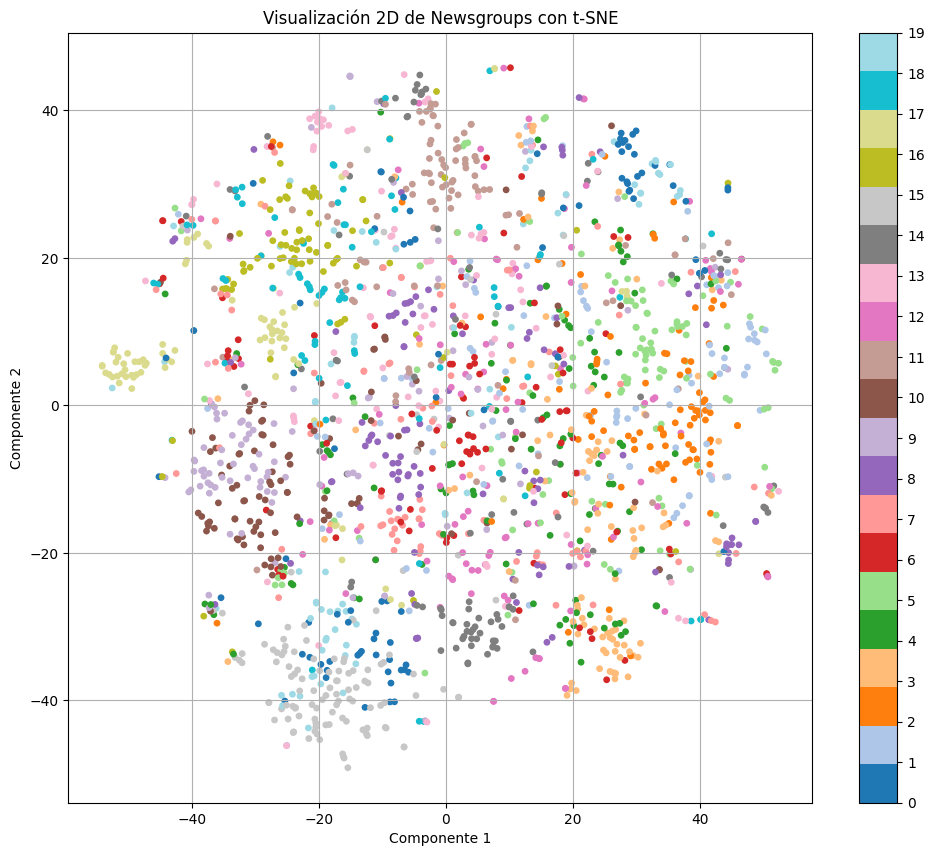

In [ ]:
from sklearn.manifold import TSNE
import numpy as np

# Debido al alto volumen, reducimos a una muestra (por tiempo y rendimiento)
sample_size = 2000
X_sample = X[:sample_size].toarray()
y_sample = y[:sample_size]

# 6. Aplicar t-SNE
tsne = TSNE(n_components=2, perplexity=40, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X_sample)

# 7. Visualizar en 2D
plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap='tab20', s=15)
plt.colorbar(scatter, ticks=range(20))
plt.title("Visualización 2D de Newsgroups con t-SNE")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.show()
